# Random controls for GT-centered retrieval

Saved retrieval outputs from notebook 08 are compared with global, same-domain, and domain-distribution-matched random neighbors. The feature matrix and patient order are reused without recomputing embeddings.

In [1]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

Project: /home/mandrakedrink/projects/research_ts_bs


In [2]:
from brats_pipeline.retrieval import BaselineContext
from brats_pipeline.common import save_dataframe as _save_dataframe, safe_display

In [3]:


import os
import json
import math
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configuration

In [4]:


CFG = {
    "project_root": str(PROJECT_ROOT),
    "source_08_dir": "docs/08_static_digital_twin_retrieval_test",
    "output_dir": "docs/08b_random_and_domain_matched_retrieval_baselines_test",

    "seed": 42,
    "n_random_repeats": 1000,
    "top_k": [1, 3, 5, 10],

    "metric_cols": [
        "same_domain_rate",
        "cross_domain_rate",
        "same_ET_presence_rate",
        "mean_abs_log1p_WT_diff",
        "mean_abs_log1p_TC_diff",
        "mean_abs_log1p_ET_diff",
        "mean_tumor_feature_z_distance",
        "mean_WT_centroid_distance",
        "mean_TC_centroid_distance",
        "mean_ET_centroid_distance",
    ],

    "primary_retrieval_space": "embedding",
    "primary_k": 5,

    "baseline_types": [
        "global_random",
        "same_domain_random_strict",
        "domain_distribution_matched_random",
    ],
}

PROJECT_ROOT = Path(CFG["project_root"]).expanduser().resolve()
OUT_DIR = (PROJECT_ROOT / CFG["output_dir"]).resolve()
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
REPORT_DIR = OUT_DIR / "reports"
LOG_DIR = OUT_DIR / "logs"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(CFG["seed"])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("n_random_repeats:", CFG["n_random_repeats"])
print("top_k:", CFG["top_k"])

PROJECT_ROOT: /home/mandrakedrink/projects/research_ts_bs
OUT_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test
n_random_repeats: 1000
top_k: [1, 3, 5, 10]


In [5]:
save_dataframe = partial(_save_dataframe, table_dir=TABLE_DIR)




def resolve_08_artifact(relative_path, required=True):
    return resolve_existing_path(
        Path(CFG["source_08_dir"]) / relative_path,
        required=required,
        label=f"08 artifact {relative_path}",
    )

## Load notebook 08 artifacts

In [6]:


paths = {
    "eval_patient_list": resolve_08_artifact("tables/02_eval_patient_list.csv"),
    "features": resolve_08_artifact("tables/03_patient_tumor_phenotype_features.csv"),
    "neighbors": resolve_08_artifact("tables/08_topk_neighbors_long.csv"),
    "query_metrics": resolve_08_artifact("tables/09_query_level_retrieval_metrics.csv"),
    "overall_metrics": resolve_08_artifact("tables/10_overall_retrieval_metrics.csv"),
    "domain_metrics": resolve_08_artifact("tables/11_domain_stratified_retrieval_metrics.csv"),
    "tumor_feature_z": resolve_08_artifact("embeddings/tumor_feature_z.npy"),
    "tumor_feature_raw_features": resolve_08_artifact("embeddings/tumor_feature_raw_features.csv"),
}

artifact_df = pd.DataFrame([
    {"artifact": k, "path": str(v), "exists": v.exists() if v is not None else False}
    for k, v in paths.items()
])
safe_display("Resolved 08 artifacts", artifact_df, n=20)
save_dataframe(artifact_df, "01_resolved_08_artifacts")

eval_df = pd.read_csv(paths["eval_patient_list"])
features_df = pd.read_csv(paths["features"])
neighbors_df = pd.read_csv(paths["neighbors"])
query_metrics_df = pd.read_csv(paths["query_metrics"])
overall_metrics_df = pd.read_csv(paths["overall_metrics"])
domain_metrics_df = pd.read_csv(paths["domain_metrics"])

tumor_feature_z = np.load(paths["tumor_feature_z"])
tumor_feature_raw_df = pd.read_csv(paths["tumor_feature_raw_features"])

print("eval_df:", eval_df.shape)
print("features_df:", features_df.shape)
print("neighbors_df:", neighbors_df.shape)
print("query_metrics_df:", query_metrics_df.shape)
print("overall_metrics_df:", overall_metrics_df.shape)
print("domain_metrics_df:", domain_metrics_df.shape)
print("tumor_feature_z:", tumor_feature_z.shape)

### Resolved 08 artifacts

,artifact,path,exists
0,eval_patient_list,/home/mandrakedrink/projects/research_ts_bs/do...,True
1,features,/home/mandrakedrink/projects/research_ts_bs/do...,True
2,neighbors,/home/mandrakedrink/projects/research_ts_bs/do...,True
3,query_metrics,/home/mandrakedrink/projects/research_ts_bs/do...,True
4,overall_metrics,/home/mandrakedrink/projects/research_ts_bs/do...,True
5,domain_metrics,/home/mandrakedrink/projects/research_ts_bs/do...,True
6,tumor_feature_z,/home/mandrakedrink/projects/research_ts_bs/do...,True
7,tumor_feature_raw_features,/home/mandrakedrink/projects/research_ts_bs/do...,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/01_resolved_08_artifacts.csv
eval_df: (211, 3)
features_df: (211, 75)
neighbors_df: (18990, 29)
query_metrics_df: (7596, 17)
overall_metrics_df: (36, 16)
domain_metrics_df: (144, 14)
tumor_feature_z: (211, 32)


## Schema and integrity validation

In [7]:


required_eval_cols = {"patient_id", "client_domain", "split"}
required_feature_cols = {"patient_id", "log1p_WT_vox", "log1p_TC_vox", "log1p_ET_vox", "ET_present"}
required_neighbor_cols = {
    "experiment_key", "retrieval_space",
    "query_patient_id", "query_domain",
    "neighbor_rank", "neighbor_patient_id", "neighbor_domain",
}
required_overall_cols = {
    "experiment_key", "retrieval_space", "k",
    "same_domain_rate", "same_ET_presence_rate",
    "mean_abs_log1p_ET_diff", "mean_tumor_feature_z_distance",
}

checks = []

def check_cols(df, required, name):
    missing = sorted(required - set(df.columns))
    checks.append({
        "check": f"{name}_required_columns",
        "passed": len(missing) == 0,
        "details": ", ".join(missing)
    })
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

check_cols(eval_df, required_eval_cols, "eval_df")
check_cols(features_df, required_feature_cols, "features_df")
check_cols(neighbors_df, required_neighbor_cols, "neighbors_df")
check_cols(overall_metrics_df, required_overall_cols, "overall_metrics_df")

eval_ids = eval_df["patient_id"].astype(str).tolist()
feature_ids = features_df["patient_id"].astype(str).tolist()
raw_feature_ids = tumor_feature_raw_df["patient_id"].astype(str).tolist()

checks.extend([
    {
        "check": "features_patient_order_matches_eval",
        "passed": feature_ids == eval_ids,
        "details": f"features={len(feature_ids)}, eval={len(eval_ids)}",
    },
    {
        "check": "raw_feature_patient_order_matches_eval",
        "passed": raw_feature_ids == eval_ids,
        "details": f"raw_features={len(raw_feature_ids)}, eval={len(eval_ids)}",
    },
    {
        "check": "tumor_feature_z_shape_matches_eval",
        "passed": tumor_feature_z.shape[0] == len(eval_df),
        "details": str(tumor_feature_z.shape),
    },
    {
        "check": "tumor_feature_z_all_finite",
        "passed": bool(np.isfinite(tumor_feature_z).all()),
        "details": "",
    },
])

available_k = sorted(neighbors_df["neighbor_rank"].dropna().astype(int).unique())
checks.append({
    "check": "requested_k_available",
    "passed": all(k in available_k for k in CFG["top_k"]),
    "details": f"available ranks: {available_k[:15]}...",
})

integrity_df = pd.DataFrame(checks)
safe_display("Integrity checks", integrity_df, n=50)
save_dataframe(integrity_df, "02_integrity_checks")

if not integrity_df["passed"].all():
    raise ValueError("Integrity checks failed.")

### Integrity checks

,check,passed,details
0,eval_df_required_columns,True,
1,features_df_required_columns,True,
2,neighbors_df_required_columns,True,
3,overall_metrics_df_required_columns,True,
4,features_patient_order_matches_eval,True,"features=211, eval=211"
5,raw_feature_patient_order_matches_eval,True,"raw_features=211, eval=211"
6,tumor_feature_z_shape_matches_eval,True,"(211, 32)"
7,tumor_feature_z_all_finite,True,
8,requested_k_available,True,"available ranks: [np.int64(1), np.int64(2), np..."


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/02_integrity_checks.csv


In [8]:


patient_df = eval_df.copy()
patient_df["patient_id"] = patient_df["patient_id"].astype(str)
patient_df["client_domain"] = patient_df["client_domain"].astype(str)

features_df = features_df.copy()
features_df["patient_id"] = features_df["patient_id"].astype(str)
features_df = features_df.set_index("patient_id").loc[patient_df["patient_id"]].reset_index()

domain_arr = patient_df["client_domain"].to_numpy()
patient_ids = patient_df["patient_id"].to_numpy()
N = len(patient_df)

pid_to_idx = {pid: i for i, pid in enumerate(patient_ids)}
idx_to_pid = {i: pid for i, pid in enumerate(patient_ids)}

domain_counts = patient_df["client_domain"].value_counts().sort_index()
domain_counts_df = domain_counts.rename_axis("client_domain").reset_index(name="n")
safe_display("Domain counts", domain_counts_df, n=20)
save_dataframe(domain_counts_df, "03_domain_counts")

def arr_col(col, default=np.nan):
    if col in features_df.columns:
        return pd.to_numeric(features_df[col], errors="coerce").to_numpy()
    return np.full(N, default, dtype=float)

log1p_WT = arr_col("log1p_WT_vox")
log1p_TC = arr_col("log1p_TC_vox")
log1p_ET = arr_col("log1p_ET_vox")
ET_present = arr_col("ET_present", default=0).astype(float) > 0.5

centroid_cols = {
    "WT": ["WT_centroid_x", "WT_centroid_y", "WT_centroid_z"],
    "TC": ["TC_centroid_x", "TC_centroid_y", "TC_centroid_z"],
    "ET": ["ET_centroid_x", "ET_centroid_y", "ET_centroid_z"],
}

centroids = {}
for region, cols in centroid_cols.items():
    if all(c in features_df.columns for c in cols):
        centroids[region] = features_df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    else:
        centroids[region] = np.full((N, 3), np.nan, dtype=float)

expected_same_by_idx = np.array([
    (domain_counts[domain_arr[i]] - 1) / (N - 1)
    for i in range(N)
], dtype=float)

feature_lookup_df = pd.DataFrame({
    "patient_id": patient_ids,
    "client_domain": domain_arr,
    "ET_present": ET_present.astype(int),
    "log1p_WT_vox": log1p_WT,
    "log1p_TC_vox": log1p_TC,
    "log1p_ET_vox": log1p_ET,
    "expected_same_domain_rate": expected_same_by_idx,
})

safe_display("Patient feature lookup", feature_lookup_df, n=10)
save_dataframe(feature_lookup_df, "04_patient_feature_lookup")

### Domain counts

,client_domain,n
0,TCGA-GBM,20
1,TCGA-LGG,13
2,UCSF-PDGM,76
3,UPENN-GBM,102


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/03_domain_counts.csv


### Patient feature lookup

,patient_id,client_domain,ET_present,log1p_WT_vox,log1p_TC_vox,log1p_ET_vox,expected_same_domain_rate
0,BraTS2021_00003,UCSF-PDGM,1,11.505296,10.632653,10.096296,0.357143
1,BraTS2021_00009,UCSF-PDGM,1,10.220267,7.531552,7.300473,0.357143
2,BraTS2021_00014,UCSF-PDGM,1,10.554744,7.847763,7.846981,0.357143
3,BraTS2021_00016,UCSF-PDGM,1,11.219185,10.056252,9.448963,0.357143
4,BraTS2021_00019,UCSF-PDGM,1,11.870586,9.391077,9.247251,0.357143
5,BraTS2021_00046,UCSF-PDGM,1,10.428009,8.937744,8.830835,0.357143
6,BraTS2021_00059,UCSF-PDGM,1,11.694705,10.317516,10.049145,0.357143
7,BraTS2021_00060,UCSF-PDGM,1,12.389951,11.599718,11.032160,0.357143
8,BraTS2021_00061,UCSF-PDGM,1,9.876373,9.138630,8.625150,0.357143
9,BraTS2021_00064,UCSF-PDGM,1,11.527095,10.766989,10.178160,0.357143


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/04_patient_feature_lookup.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/04_patient_feature_lookup.csv')

## Metric functions

In [9]:
baseline = BaselineContext(
    patient_ids=patient_ids, domain_arr=domain_arr, ET_present=ET_present,
    log1p_WT=log1p_WT, log1p_TC=log1p_TC, log1p_ET=log1p_ET,
    centroids=centroids, tumor_feature_z=tumor_feature_z,
    expected_same_by_idx=expected_same_by_idx, neighbors_df=neighbors_df,
    metric_cols=CFG["metric_cols"],
)
centroid_distance = baseline.centroid_distance
pair_metric_dict = baseline.pair_metric_dict
evaluate_sampled_neighbors = baseline.evaluate_sampled_neighbors
sample_global_random = baseline.sample_global_random
sample_same_domain_strict = baseline.sample_same_domain_strict
get_observed_domain_counts = baseline.get_observed_domain_counts
sample_domain_distribution_matched = baseline.sample_domain_distribution_matched
evaluate_sampled_neighbors_by_query_domain = baseline.evaluate_sampled_neighbors_by_query_domain



## Random neighbor samplers

In [10]:


all_indices = np.arange(N)
indices_by_domain = {d: np.where(domain_arr == d)[0] for d in sorted(set(domain_arr))}


same_domain_capacity_rows = []
for k in CFG["top_k"]:
    sampled = sample_same_domain_strict(k, rng)
    sizes = [len(v) for v in sampled.values()]
    same_domain_capacity_rows.append({
        "k": k,
        "effective_k_mean": float(np.mean(sizes)),
        "effective_k_min": int(np.min(sizes)),
        "effective_k_max": int(np.max(sizes)),
        "n_queries_limited": int(sum(s < k for s in sizes)),
    })

same_domain_capacity_df = pd.DataFrame(same_domain_capacity_rows)
safe_display("Same-domain strict baseline capacity", same_domain_capacity_df)
save_dataframe(same_domain_capacity_df, "05_same_domain_strict_capacity")

### Same-domain strict baseline capacity

,k,effective_k_mean,effective_k_min,effective_k_max,n_queries_limited
0,1,1.0,1,1,0
1,3,3.0,3,3,0
2,5,5.0,5,5,0
3,10,10.0,10,10,0


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/05_same_domain_strict_capacity.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/05_same_domain_strict_capacity.csv')

## Run random baselines

In [11]:


experiments = sorted(overall_metrics_df["experiment_key"].dropna().astype(str).unique())
retrieval_spaces = sorted(overall_metrics_df["retrieval_space"].dropna().astype(str).unique())
ks = sorted([int(k) for k in CFG["top_k"]])
R = int(CFG["n_random_repeats"])

print("experiments:", experiments)
print("retrieval_spaces:", retrieval_spaces)
print("k:", ks)
print("repeats:", R)

run_rows = []

for repeat_idx in range(R):
    if (repeat_idx + 1) % max(1, R // 10) == 0:
        print(f"baseline repeat {repeat_idx + 1}/{R}")

    for k in ks:
        global_metrics = evaluate_sampled_neighbors(sample_global_random(k, rng))
        same_domain_metrics = evaluate_sampled_neighbors(sample_same_domain_strict(k, rng))

        for exp_key in experiments:
            for space in retrieval_spaces:
                run_rows.append({
                    "baseline_type": "global_random",
                    "repeat_idx": repeat_idx,
                    "experiment_key": exp_key,
                    "retrieval_space": space,
                    "k": k,
                    **global_metrics,
                })
                run_rows.append({
                    "baseline_type": "same_domain_random_strict",
                    "repeat_idx": repeat_idx,
                    "experiment_key": exp_key,
                    "retrieval_space": space,
                    "k": k,
                    **same_domain_metrics,
                })

                matched_metrics = evaluate_sampled_neighbors(
                    sample_domain_distribution_matched(exp_key, space, k, rng)
                )
                run_rows.append({
                    "baseline_type": "domain_distribution_matched_random",
                    "repeat_idx": repeat_idx,
                    "experiment_key": exp_key,
                    "retrieval_space": space,
                    "k": k,
                    **matched_metrics,
                })

baseline_run_metrics_df = pd.DataFrame(run_rows)
safe_display("Random baseline run metrics", baseline_run_metrics_df, n=10)
save_dataframe(baseline_run_metrics_df, "06_random_baseline_run_metrics")

experiments: ['centralized_s32_cew', 'fedavg_s32_cew', 'fedprox_s32_cew']
retrieval_spaces: ['embedding', 'hybrid', 'tumor_features']
k: [1, 3, 5, 10]
repeats: 1000
baseline repeat 100/1000
baseline repeat 200/1000
baseline repeat 300/1000
baseline repeat 400/1000
baseline repeat 500/1000
baseline repeat 600/1000
baseline repeat 700/1000
baseline repeat 800/1000
baseline repeat 900/1000
baseline repeat 1000/1000


### Random baseline run metrics

,baseline_type,repeat_idx,experiment_key,retrieval_space,k,n_queries,n_pairs,effective_k_mean,effective_k_min,effective_k_max,same_domain_rate,cross_domain_rate,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance,mean_WT_centroid_distance,mean_TC_centroid_distance,mean_ET_centroid_distance
0,global_random,0,centralized_s32_cew,embedding,1,211,211,1.0,1,1,0.341232,0.658768,0.962085,0.916035,1.354409,1.664496,1.379648,0.258815,0.278479,0.277106
1,same_domain_random_strict,0,centralized_s32_cew,embedding,1,211,211,1.0,1,1,1.000000,0.000000,0.971564,0.855224,1.196397,1.257280,1.379182,0.275677,0.299964,0.300806
2,domain_distribution_matched_random,0,centralized_s32_cew,embedding,1,211,211,1.0,1,1,0.758294,0.241706,0.981043,0.867302,1.270973,1.327729,1.365403,0.262484,0.280678,0.280921
3,global_random,0,centralized_s32_cew,hybrid,1,211,211,1.0,1,1,0.341232,0.658768,0.962085,0.916035,1.354409,1.664496,1.379648,0.258815,0.278479,0.277106
4,same_domain_random_strict,0,centralized_s32_cew,hybrid,1,211,211,1.0,1,1,1.000000,0.000000,0.971564,0.855224,1.196397,1.257280,1.379182,0.275677,0.299964,0.300806
5,domain_distribution_matched_random,0,centralized_s32_cew,hybrid,1,211,211,1.0,1,1,0.649289,0.350711,0.981043,0.785385,1.155023,1.180080,1.349814,0.268714,0.286626,0.288035
6,global_random,0,centralized_s32_cew,tumor_features,1,211,211,1.0,1,1,0.341232,0.658768,0.962085,0.916035,1.354409,1.664496,1.379648,0.258815,0.278479,0.277106
7,same_domain_random_strict,0,centralized_s32_cew,tumor_features,1,211,211,1.0,1,1,1.000000,0.000000,0.971564,0.855224,1.196397,1.257280,1.379182,0.275677,0.299964,0.300806
8,domain_distribution_matched_random,0,centralized_s32_cew,tumor_features,1,211,211,1.0,1,1,0.445498,0.554502,0.990521,0.897584,1.315812,1.308670,1.371350,0.268231,0.290755,0.290991
9,global_random,0,fedavg_s32_cew,embedding,1,211,211,1.0,1,1,0.341232,0.658768,0.962085,0.916035,1.354409,1.664496,1.379648,0.258815,0.278479,0.277106


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/06_random_baseline_run_metrics.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/06_random_baseline_run_metrics.csv')

## Summarize random baseline distributions

In [12]:


summary_rows = []

for (baseline_type, exp_key, space, k), g in baseline_run_metrics_df.groupby(
    ["baseline_type", "experiment_key", "retrieval_space", "k"]
):
    for metric in CFG["metric_cols"] + ["effective_k_mean", "n_pairs"]:
        if metric not in g.columns:
            continue
        vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        summary_rows.append({
            "baseline_type": baseline_type,
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": int(k),
            "metric": metric,
            "baseline_mean": float(np.mean(vals)),
            "baseline_std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
            "baseline_ci95_low": float(np.quantile(vals, 0.025)),
            "baseline_ci95_high": float(np.quantile(vals, 0.975)),
            "n_repeats": int(len(vals)),
        })

baseline_summary_df = pd.DataFrame(summary_rows)
safe_display("Random baseline summary", baseline_summary_df, n=30)
save_dataframe(baseline_summary_df, "07_random_baseline_summary")

### Random baseline summary

,baseline_type,experiment_key,retrieval_space,k,metric,baseline_mean,baseline_std,baseline_ci95_low,baseline_ci95_high,n_repeats
0,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_domain_rate,0.758294,2.221557e-16,0.758294,0.758294,1000
1,domain_distribution_matched_random,centralized_s32_cew,embedding,1,cross_domain_rate,0.241706,5.553893e-17,0.241706,0.241706,1000
2,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_ET_presence_rate,0.981299,5.786213e-03,0.966825,0.990521,1000
3,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_abs_log1p_WT_diff,0.847705,4.204973e-02,0.764962,0.937672,1000
4,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_abs_log1p_TC_diff,1.255162,5.788789e-02,1.137147,1.370691,1000
5,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_abs_log1p_ET_diff,1.316293,6.846897e-02,1.179859,1.448344,1000
6,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_tumor_feature_z_distance,1.369906,2.009487e-02,1.330873,1.407621,1000
7,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_WT_centroid_distance,0.265907,6.567454e-03,0.253514,0.278715,1000
8,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_TC_centroid_distance,0.286127,6.909117e-03,0.273173,0.300045,1000
9,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_ET_centroid_distance,0.286533,6.999553e-03,0.272817,0.300477,1000


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/07_random_baseline_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/07_random_baseline_summary.csv')

## Compare observed retrieval to random baselines

In [13]:


metric_direction = {
    "same_ET_presence_rate": "higher_is_better",
    "mean_abs_log1p_WT_diff": "lower_is_better",
    "mean_abs_log1p_TC_diff": "lower_is_better",
    "mean_abs_log1p_ET_diff": "lower_is_better",
    "mean_tumor_feature_z_distance": "lower_is_better",
    "mean_WT_centroid_distance": "lower_is_better",
    "mean_TC_centroid_distance": "lower_is_better",
    "mean_ET_centroid_distance": "lower_is_better",
    "same_domain_rate": "domain_leakage_metric",
    "cross_domain_rate": "domain_leakage_metric",
}

observed_long_rows = []
for _, row in overall_metrics_df.iterrows():
    for metric in CFG["metric_cols"]:
        if metric not in overall_metrics_df.columns:
            continue
        observed_long_rows.append({
            "experiment_key": str(row["experiment_key"]),
            "retrieval_space": str(row["retrieval_space"]),
            "k": int(row["k"]),
            "metric": metric,
            "observed_value": float(row[metric]) if pd.notna(row[metric]) else np.nan,
        })

observed_long_df = pd.DataFrame(observed_long_rows)
comparison_rows = []

for _, obs in observed_long_df.iterrows():
    exp_key = obs["experiment_key"]
    space = obs["retrieval_space"]
    k = int(obs["k"])
    metric = obs["metric"]
    observed_value = obs["observed_value"]

    for baseline_type in CFG["baseline_types"]:
        g = baseline_run_metrics_df[
            (baseline_run_metrics_df["baseline_type"] == baseline_type)
            & (baseline_run_metrics_df["experiment_key"] == exp_key)
            & (baseline_run_metrics_df["retrieval_space"] == space)
            & (baseline_run_metrics_df["k"].astype(int) == k)
        ]
        if len(g) == 0 or metric not in g.columns or pd.isna(observed_value):
            continue

        vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            continue

        baseline_mean = float(np.mean(vals))
        baseline_low = float(np.quantile(vals, 0.025))
        baseline_high = float(np.quantile(vals, 0.975))
        percentile = float(np.mean(vals <= observed_value))
        direction = metric_direction.get(metric, "unspecified")

        if direction == "lower_is_better":
            better_p = float(np.mean(vals <= observed_value))
            baseline_flag = "better_than_random" if percentile < 0.025 else ("worse_than_random" if percentile > 0.975 else "within_random_interval")
        elif direction == "higher_is_better":
            better_p = float(np.mean(vals >= observed_value))
            baseline_flag = "better_than_random" if percentile > 0.975 else ("worse_than_random" if percentile < 0.025 else "within_random_interval")
        else:
            better_p = np.nan
            baseline_flag = "domain_leakage_or_composition_metric"

        comparison_rows.append({
            "baseline_type": baseline_type,
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": k,
            "metric": metric,
            "direction": direction,
            "observed_value": observed_value,
            "baseline_mean": baseline_mean,
            "baseline_ci95_low": baseline_low,
            "baseline_ci95_high": baseline_high,
            "observed_minus_baseline_mean": float(observed_value - baseline_mean),
            "observed_percentile_within_baseline": percentile,
            "one_sided_random_p_for_better": better_p,
            "baseline_flag": baseline_flag,
            "n_repeats": int(len(vals)),
        })

actual_vs_baseline_df = pd.DataFrame(comparison_rows)
safe_display("Observed retrieval vs random baselines", actual_vs_baseline_df, n=40)
save_dataframe(actual_vs_baseline_df, "08_observed_vs_random_baselines")

### Observed retrieval vs random baselines

,baseline_type,experiment_key,retrieval_space,k,metric,direction,observed_value,baseline_mean,baseline_ci95_low,baseline_ci95_high,observed_minus_baseline_mean,observed_percentile_within_baseline,one_sided_random_p_for_better,baseline_flag,n_repeats
0,global_random,centralized_s32_cew,embedding,1,same_domain_rate,domain_leakage_metric,0.758294,0.373024,0.308057,0.436019,3.852701e-01,1.000,NaN,domain_leakage_or_composition_metric,1000
1,same_domain_random_strict,centralized_s32_cew,embedding,1,same_domain_rate,domain_leakage_metric,0.758294,1.000000,1.000000,1.000000,-2.417062e-01,0.000,NaN,domain_leakage_or_composition_metric,1000
2,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_domain_rate,domain_leakage_metric,0.758294,0.758294,0.758294,0.758294,-2.220446e-16,1.000,NaN,domain_leakage_or_composition_metric,1000
3,global_random,centralized_s32_cew,embedding,1,cross_domain_rate,domain_leakage_metric,0.241706,0.626976,0.563981,0.691943,-3.852701e-01,0.000,NaN,domain_leakage_or_composition_metric,1000
4,same_domain_random_strict,centralized_s32_cew,embedding,1,cross_domain_rate,domain_leakage_metric,0.241706,0.000000,0.000000,0.000000,2.417062e-01,1.000,NaN,domain_leakage_or_composition_metric,1000
5,domain_distribution_matched_random,centralized_s32_cew,embedding,1,cross_domain_rate,domain_leakage_metric,0.241706,0.241706,0.241706,0.241706,-1.110223e-16,0.000,NaN,domain_leakage_or_composition_metric,1000
6,global_random,centralized_s32_cew,embedding,1,same_ET_presence_rate,higher_is_better,0.985782,0.971507,0.952607,0.985782,1.427488e-02,0.997,0.053,better_than_random,1000
7,same_domain_random_strict,centralized_s32_cew,embedding,1,same_ET_presence_rate,higher_is_better,0.985782,0.976033,0.962085,0.990521,9.748815e-03,0.959,0.152,within_random_interval,1000
8,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_ET_presence_rate,higher_is_better,0.985782,0.981299,0.966825,0.990521,4.483412e-03,0.896,0.361,within_random_interval,1000
9,global_random,centralized_s32_cew,embedding,1,mean_abs_log1p_WT_diff,lower_is_better,0.537291,0.861399,0.784839,0.942507,-3.241074e-01,0.000,0.000,better_than_random,1000


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/08_observed_vs_random_baselines.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/08_observed_vs_random_baselines.csv')

## Primary comparison: embedding retrieval at k = 5

In [14]:


primary_space = CFG["primary_retrieval_space"]
primary_k = int(CFG["primary_k"])
primary_metrics = [
    "same_domain_rate",
    "same_ET_presence_rate",
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]

primary_df = actual_vs_baseline_df[
    (actual_vs_baseline_df["retrieval_space"] == primary_space)
    & (actual_vs_baseline_df["k"].astype(int) == primary_k)
    & (actual_vs_baseline_df["metric"].isin(primary_metrics))
].copy()

compact_rows = []
for (exp_key, metric), g in primary_df.groupby(["experiment_key", "metric"]):
    row = {
        "experiment_key": exp_key,
        "retrieval_space": primary_space,
        "k": primary_k,
        "metric": metric,
        "observed": g["observed_value"].iloc[0],
    }
    for _, br in g.iterrows():
        b = br["baseline_type"]
        row[f"{b}_mean"] = br["baseline_mean"]
        row[f"{b}_ci95_low"] = br["baseline_ci95_low"]
        row[f"{b}_ci95_high"] = br["baseline_ci95_high"]
        row[f"{b}_obs_minus_mean"] = br["observed_minus_baseline_mean"]
        row[f"{b}_flag"] = br["baseline_flag"]
    compact_rows.append(row)

primary_compact_df = pd.DataFrame(compact_rows)
safe_display("Primary retrieval comparison: embedding @k=5", primary_compact_df, n=80)
save_dataframe(primary_compact_df, "09_primary_baseline_comparison_embedding_k5")

### Primary retrieval comparison: embedding @k=5

,experiment_key,retrieval_space,k,metric,observed,global_random_mean,global_random_ci95_low,global_random_ci95_high,global_random_obs_minus_mean,global_random_flag,same_domain_random_strict_mean,same_domain_random_strict_ci95_low,same_domain_random_strict_ci95_high,same_domain_random_strict_obs_minus_mean,same_domain_random_strict_flag,domain_distribution_matched_random_mean,domain_distribution_matched_random_ci95_low,domain_distribution_matched_random_ci95_high,domain_distribution_matched_random_obs_minus_mean,domain_distribution_matched_random_flag
0,centralized_s32_cew,embedding,5,mean_abs_log1p_ET_diff,0.750378,1.488602,1.412672,1.569565,-0.738223,better_than_random,1.330541,1.272530,1.392584,-0.580162,better_than_random,1.327893,1.263865,1.388180,-5.775151e-01,better_than_random
1,centralized_s32_cew,embedding,5,mean_abs_log1p_TC_diff,0.631099,1.270223,1.218621,1.319557,-0.639123,better_than_random,1.260364,1.211683,1.310595,-0.629265,better_than_random,1.264229,1.213766,1.315145,-6.331296e-01,better_than_random
2,centralized_s32_cew,embedding,5,mean_abs_log1p_WT_diff,0.568519,0.863426,0.828470,0.897872,-0.294907,better_than_random,0.852754,0.818935,0.887293,-0.284235,better_than_random,0.854828,0.817870,0.891161,-2.863092e-01,better_than_random
3,centralized_s32_cew,embedding,5,mean_tumor_feature_z_distance,1.197167,1.387842,1.371065,1.404244,-0.190676,better_than_random,1.369177,1.353397,1.385007,-0.172010,better_than_random,1.374432,1.357850,1.391001,-1.772650e-01,better_than_random
4,centralized_s32_cew,embedding,5,same_ET_presence_rate,0.984834,0.971648,0.964929,0.978199,0.013186,better_than_random,0.976279,0.970616,0.981991,0.008555,better_than_random,0.980298,0.975355,0.984834,4.536493e-03,within_random_interval
5,centralized_s32_cew,embedding,5,same_domain_rate,0.679621,0.373587,0.346919,0.402844,0.306034,domain_leakage_or_composition_metric,1.000000,1.000000,1.000000,-0.320379,domain_leakage_or_composition_metric,0.679621,0.679621,0.679621,1.110223e-16,domain_leakage_or_composition_metric
6,fedavg_s32_cew,embedding,5,mean_abs_log1p_ET_diff,0.686743,1.488602,1.412672,1.569565,-0.801859,better_than_random,1.330541,1.272530,1.392584,-0.643798,better_than_random,1.319436,1.260030,1.379128,-6.326930e-01,better_than_random
7,fedavg_s32_cew,embedding,5,mean_abs_log1p_TC_diff,0.577411,1.270223,1.218621,1.319557,-0.692812,better_than_random,1.260364,1.211683,1.310595,-0.682953,better_than_random,1.262558,1.207740,1.315609,-6.851475e-01,better_than_random
8,fedavg_s32_cew,embedding,5,mean_abs_log1p_WT_diff,0.453125,0.863426,0.828470,0.897872,-0.410301,better_than_random,0.852754,0.818935,0.887293,-0.399629,better_than_random,0.848155,0.812956,0.883214,-3.950303e-01,better_than_random
9,fedavg_s32_cew,embedding,5,mean_tumor_feature_z_distance,1.156582,1.387842,1.371065,1.404244,-0.231260,better_than_random,1.369177,1.353397,1.385007,-0.212595,better_than_random,1.375016,1.357685,1.393092,-2.184343e-01,better_than_random


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/09_primary_baseline_comparison_embedding_k5.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/09_primary_baseline_comparison_embedding_k5.csv')

## Domain-distribution control table

In [15]:


domain_control_metrics = [
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
    "same_ET_presence_rate",
]

domain_matched_control_df = actual_vs_baseline_df[
    (actual_vs_baseline_df["baseline_type"] == "domain_distribution_matched_random")
    & (actual_vs_baseline_df["retrieval_space"] == primary_space)
    & (actual_vs_baseline_df["k"].astype(int) == primary_k)
    & (actual_vs_baseline_df["metric"].isin(domain_control_metrics))
].copy()

safe_display(
    "Domain-distribution-matched random control: embedding @k=5",
    domain_matched_control_df,
    n=80
)
save_dataframe(domain_matched_control_df, "10_domain_distribution_matched_control_embedding_k5")

### Domain-distribution-matched random control: embedding @k=5

,baseline_type,experiment_key,retrieval_space,k,metric,direction,observed_value,baseline_mean,baseline_ci95_low,baseline_ci95_high,observed_minus_baseline_mean,observed_percentile_within_baseline,one_sided_random_p_for_better,baseline_flag,n_repeats
68,domain_distribution_matched_random,centralized_s32_cew,embedding,5,same_ET_presence_rate,higher_is_better,0.984834,0.980298,0.975355,0.984834,0.004536,0.959,0.041,within_random_interval,1000
71,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_abs_log1p_WT_diff,lower_is_better,0.568519,0.854828,0.817870,0.891161,-0.286309,0.000,0.000,better_than_random,1000
74,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_abs_log1p_TC_diff,lower_is_better,0.631099,1.264229,1.213766,1.315145,-0.633130,0.000,0.000,better_than_random,1000
77,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_abs_log1p_ET_diff,lower_is_better,0.750378,1.327893,1.263865,1.388180,-0.577515,0.000,0.000,better_than_random,1000
80,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_tumor_feature_z_distance,lower_is_better,1.197167,1.374432,1.357850,1.391001,-0.177265,0.000,0.000,better_than_random,1000
428,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,same_ET_presence_rate,higher_is_better,0.984834,0.980321,0.975355,0.984834,0.004513,0.964,0.037,within_random_interval,1000
431,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_abs_log1p_WT_diff,lower_is_better,0.453125,0.848155,0.812956,0.883214,-0.395030,0.000,0.000,better_than_random,1000
434,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_abs_log1p_TC_diff,lower_is_better,0.577411,1.262558,1.207740,1.315609,-0.685148,0.000,0.000,better_than_random,1000
437,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_abs_log1p_ET_diff,lower_is_better,0.686743,1.319436,1.260030,1.379128,-0.632693,0.000,0.000,better_than_random,1000
440,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_tumor_feature_z_distance,lower_is_better,1.156582,1.375016,1.357685,1.393092,-0.218434,0.000,0.000,better_than_random,1000


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/10_domain_distribution_matched_control_embedding_k5.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/10_domain_distribution_matched_control_embedding_k5.csv')

## Baseline-controlled comparison

In [16]:


verdict_rows = []

distance_metrics = [
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]
consistency_metrics = ["same_ET_presence_rate"]

for exp_key in sorted(overall_metrics_df["experiment_key"].astype(str).unique()):
    g = domain_matched_control_df[domain_matched_control_df["experiment_key"] == exp_key]
    n_dist_better = 0
    n_dist_available = 0
    n_cons_better = 0
    n_cons_available = 0
    metric_flags = {}

    for metric in distance_metrics:
        r = g[g["metric"] == metric]
        if len(r) == 0:
            continue
        n_dist_available += 1
        flag = r["baseline_flag"].iloc[0]
        metric_flags[metric] = flag
        if flag == "better_than_random":
            n_dist_better += 1

    for metric in consistency_metrics:
        r = g[g["metric"] == metric]
        if len(r) == 0:
            continue
        n_cons_available += 1
        flag = r["baseline_flag"].iloc[0]
        metric_flags[metric] = flag
        if flag == "better_than_random":
            n_cons_better += 1

    if n_dist_better >= 2:
        verdict = "stronger_than_domain_matched_random_on_multiple_distance_metrics"
    elif n_dist_better == 1:
        verdict = "partially_stronger_than_domain_matched_random"
    else:
        verdict = "not_clearly_stronger_than_domain_matched_random"

    verdict_rows.append({
        "experiment_key": exp_key,
        "retrieval_space": primary_space,
        "k": primary_k,
        "n_distance_metrics_better_than_domain_matched_random": n_dist_better,
        "n_distance_metrics_available": n_dist_available,
        "n_consistency_metrics_better_than_domain_matched_random": n_cons_better,
        "n_consistency_metrics_available": n_cons_available,
        "verdict": verdict,
        "metric_flags_json": json.dumps(metric_flags, ensure_ascii=False),
    })

verdict_df = pd.DataFrame(verdict_rows)
safe_display("Baseline-controlled comparison", verdict_df, n=20)
save_dataframe(verdict_df, "11_baseline_comparison_summary")

### Baseline-controlled comparison

,experiment_key,retrieval_space,k,n_distance_metrics_better_than_domain_matched_random,n_distance_metrics_available,n_consistency_metrics_better_than_domain_matched_random,n_consistency_metrics_available,verdict,metric_flags_json
0,centralized_s32_cew,embedding,5,4,4,0,1,stronger_than_domain_matched_random_on_multipl...,"{""mean_abs_log1p_WT_diff"": ""better_than_random..."
1,fedavg_s32_cew,embedding,5,4,4,0,1,stronger_than_domain_matched_random_on_multipl...,"{""mean_abs_log1p_WT_diff"": ""better_than_random..."
2,fedprox_s32_cew,embedding,5,4,4,0,1,stronger_than_domain_matched_random_on_multipl...,"{""mean_abs_log1p_WT_diff"": ""better_than_random..."


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/11_baseline_comparison_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/11_baseline_comparison_summary.csv')

## Domain-specific domain-matched baseline

In [17]:


R_domain = min(R, 500)
domain_run_rows = []

for repeat_idx in range(R_domain):
    for exp_key in experiments:
        matched_by_domain = evaluate_sampled_neighbors_by_query_domain(
            sample_domain_distribution_matched(exp_key, primary_space, primary_k, rng)
        )
        for _, row in matched_by_domain.iterrows():
            domain_run_rows.append({
                "baseline_type": "domain_distribution_matched_random",
                "repeat_idx": repeat_idx,
                "experiment_key": exp_key,
                "retrieval_space": primary_space,
                "k": primary_k,
                **row.to_dict(),
            })

domain_baseline_run_df = pd.DataFrame(domain_run_rows)

domain_summary_rows = []
for (baseline_type, exp_key, space, k, qdom), g in domain_baseline_run_df.groupby(
    ["baseline_type", "experiment_key", "retrieval_space", "k", "query_domain"]
):
    for metric in [
        "same_ET_presence_rate",
        "mean_abs_log1p_ET_diff",
        "mean_tumor_feature_z_distance",
        "same_domain_rate"
    ]:
        vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        domain_summary_rows.append({
            "baseline_type": baseline_type,
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": int(k),
            "query_domain": qdom,
            "metric": metric,
            "baseline_mean": float(np.mean(vals)),
            "baseline_ci95_low": float(np.quantile(vals, 0.025)),
            "baseline_ci95_high": float(np.quantile(vals, 0.975)),
            "n_repeats": int(len(vals)),
        })

domain_baseline_summary_df = pd.DataFrame(domain_summary_rows)
safe_display("Domain-stratified domain-matched random baseline", domain_baseline_summary_df, n=80)
save_dataframe(domain_baseline_run_df, "12_domain_matched_random_domain_run_metrics")
save_dataframe(domain_baseline_summary_df, "13_domain_matched_random_domain_summary")

### Domain-stratified domain-matched random baseline

,baseline_type,experiment_key,retrieval_space,k,query_domain,metric,baseline_mean,baseline_ci95_low,baseline_ci95_high,n_repeats
0,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,same_ET_presence_rate,0.986880,0.970000,1.000000,500
1,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,mean_abs_log1p_ET_diff,1.189056,0.980087,1.410396,500
2,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,mean_tumor_feature_z_distance,1.362287,1.308738,1.415014,500
3,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,same_domain_rate,0.340000,0.340000,0.340000,500
4,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,same_ET_presence_rate,0.712554,0.646154,0.769231,500
5,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,mean_abs_log1p_ET_diff,3.422186,2.959458,3.879930,500
6,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,mean_tumor_feature_z_distance,1.277147,1.219274,1.336027,500
7,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,same_domain_rate,0.553846,0.553846,0.553846,500
8,domain_distribution_matched_random,centralized_s32_cew,embedding,5,UCSF-PDGM,same_ET_presence_rate,0.998326,0.994737,1.000000,500
9,domain_distribution_matched_random,centralized_s32_cew,embedding,5,UCSF-PDGM,mean_abs_log1p_ET_diff,1.201651,1.106186,1.288778,500


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/12_domain_matched_random_domain_run_metrics.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/13_domain_matched_random_domain_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/13_domain_matched_random_domain_summary.csv')

## Figures

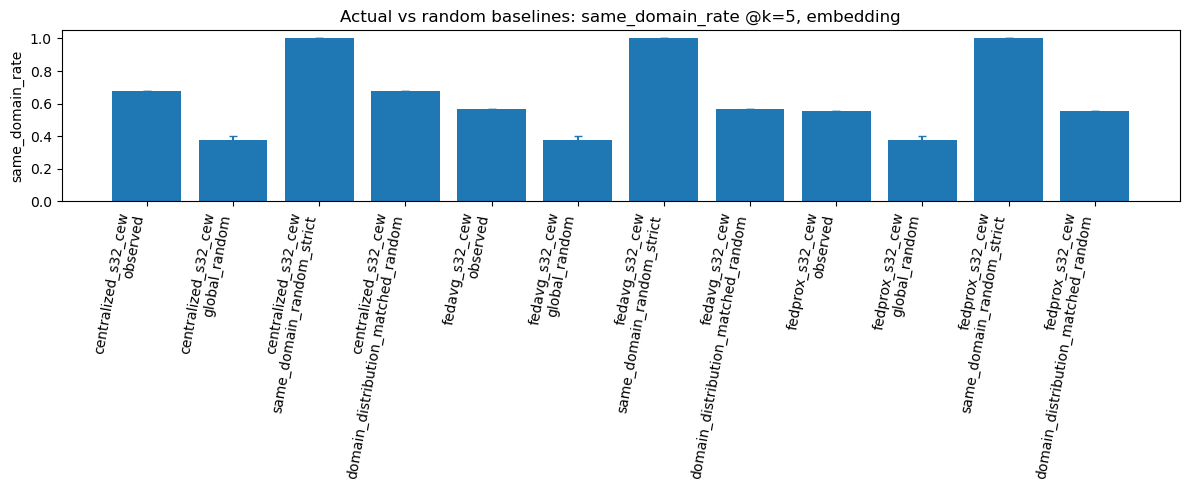

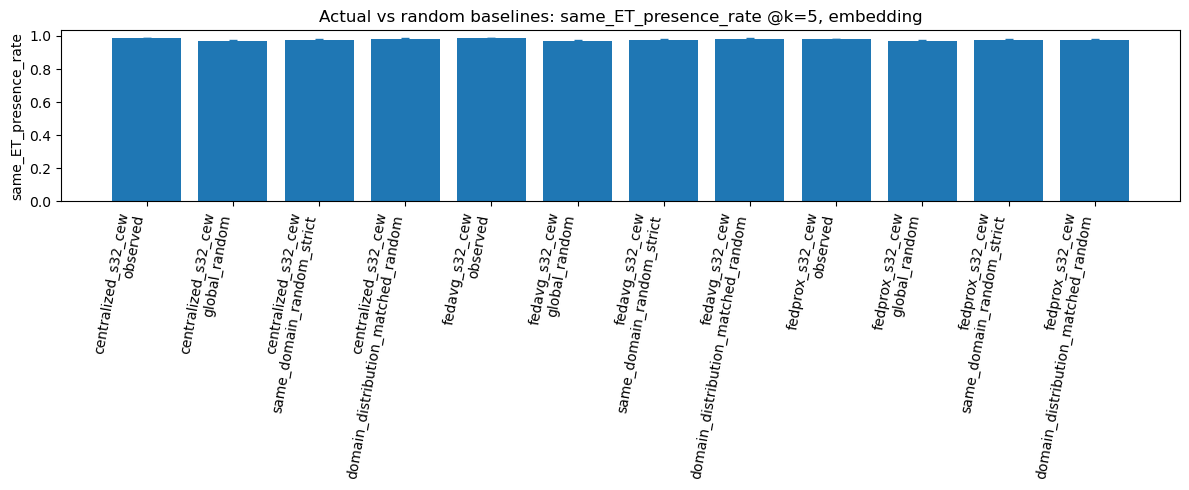

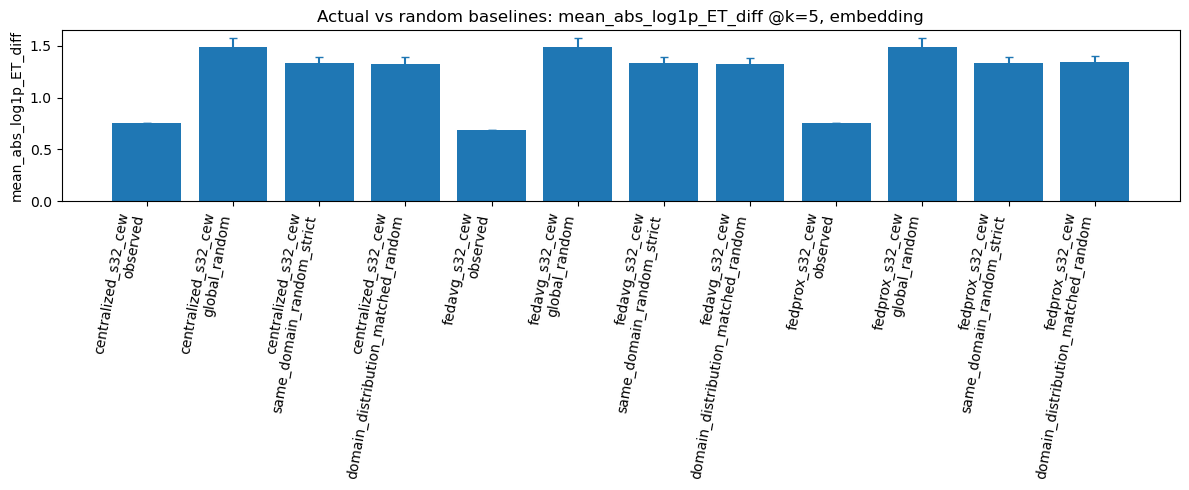

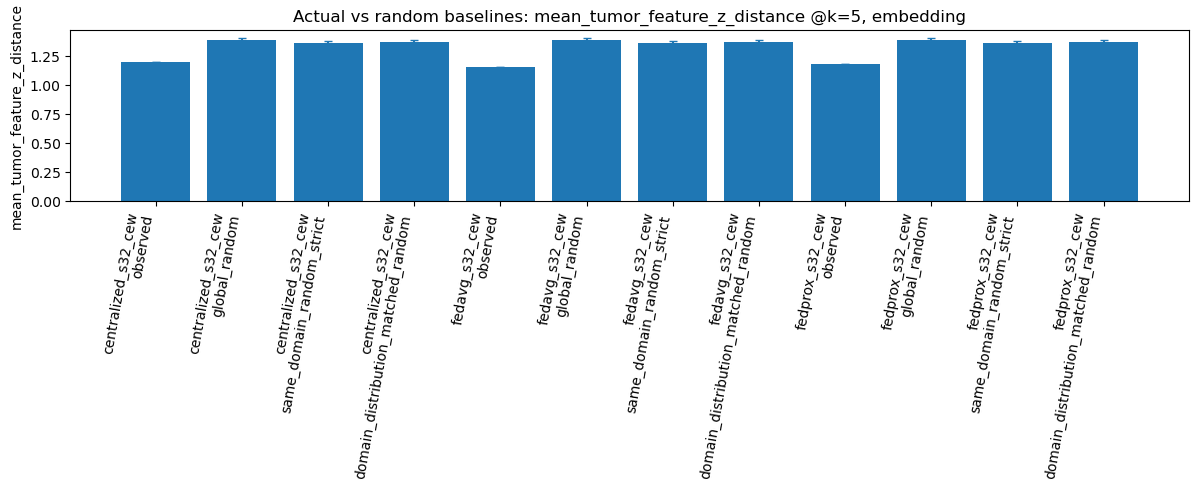

### Figure paths

,metric,png,pdf
0,same_domain_rate,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...
1,same_ET_presence_rate,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...
2,mean_abs_log1p_ET_diff,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...
3,mean_tumor_feature_z_distance,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/14_figure_paths.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/14_figure_paths.csv')

In [18]:


def plot_actual_vs_baselines(metric, retrieval_space=None, k=None):
    retrieval_space = retrieval_space or primary_space
    k = int(k or primary_k)

    df = actual_vs_baseline_df[
        (actual_vs_baseline_df["retrieval_space"] == retrieval_space)
        & (actual_vs_baseline_df["k"].astype(int) == k)
        & (actual_vs_baseline_df["metric"] == metric)
    ].copy()

    if len(df) == 0:
        print("No data for", metric, retrieval_space, k)
        return None, None

    exp_keys = sorted(df["experiment_key"].unique())
    rows = []
    for exp_key in exp_keys:
        g = df[df["experiment_key"] == exp_key]
        rows.append({
            "label": f"{exp_key}\nobserved",
            "value": g["observed_value"].iloc[0],
            "low": np.nan,
            "high": np.nan
        })
        for b in CFG["baseline_types"]:
            br = g[g["baseline_type"] == b]
            if len(br) == 0:
                continue
            rows.append({
                "label": f"{exp_key}\n{b}",
                "value": br["baseline_mean"].iloc[0],
                "low": br["baseline_ci95_low"].iloc[0],
                "high": br["baseline_ci95_high"].iloc[0],
            })

    pdf = pd.DataFrame(rows)
    x = np.arange(len(pdf))
    y = pdf["value"].to_numpy(dtype=float)

    yerr_low, yerr_high = [], []
    for _, r in pdf.iterrows():
        if pd.isna(r["low"]) or pd.isna(r["high"]):
            yerr_low.append(0.0)
            yerr_high.append(0.0)
        else:
            yerr_low.append(max(r["value"] - r["low"], 0.0))
            yerr_high.append(max(r["high"] - r["value"], 0.0))

    plt.figure(figsize=(max(12, len(pdf) * 0.55), 5))
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=np.vstack([yerr_low, yerr_high]), fmt="none", capsize=3)
    plt.xticks(x, pdf["label"], rotation=80, ha="right")
    plt.ylabel(metric)
    plt.title(f"Actual vs random baselines: {metric} @k={k}, {retrieval_space}")
    plt.tight_layout()

    png = FIG_DIR / f"actual_vs_baselines_{metric}_{retrieval_space}_k{k}.png"
    pdf_path = FIG_DIR / f"actual_vs_baselines_{metric}_{retrieval_space}_k{k}.pdf"
    plt.savefig(png, dpi=200, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return png, pdf_path

fig_rows = []
for metric in [
    "same_domain_rate",
    "same_ET_presence_rate",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance"
]:
    png, pdf_path = plot_actual_vs_baselines(metric, primary_space, primary_k)
    if png is not None:
        fig_rows.append({"metric": metric, "png": str(png), "pdf": str(pdf_path)})

figure_paths_df = pd.DataFrame(fig_rows)
safe_display("Figure paths", figure_paths_df)
save_dataframe(figure_paths_df, "14_figure_paths")

## Baseline report

In [19]:


report_verdict_df = verdict_df[
    [
        "experiment_key",
        "verdict",
        "n_distance_metrics_better_than_domain_matched_random",
        "n_distance_metrics_available",
        "n_consistency_metrics_better_than_domain_matched_random",
        "n_consistency_metrics_available",
    ]
].copy()

report_verdict_df = report_verdict_df.rename(
    columns={
        "experiment_key": "Experiment",
        "verdict": "Verdict",
        "n_distance_metrics_better_than_domain_matched_random": "Distance metrics better",
        "n_distance_metrics_available": "Distance metrics total",
        "n_consistency_metrics_better_than_domain_matched_random": "Consistency metrics better",
        "n_consistency_metrics_available": "Consistency metrics total",
    }
)


report_primary_df = primary_compact_df[
    primary_compact_df["metric"].isin(primary_metrics)
].copy()

report_primary_df = report_primary_df[
    [
        "experiment_key",
        "metric",
        "observed",
        "global_random_mean",
        "domain_distribution_matched_random_mean",
        "domain_distribution_matched_random_flag",
    ]
].rename(
    columns={
        "experiment_key": "Experiment",
        "metric": "Metric",
        "observed": "Observed",
        "global_random_mean": "Global random",
        "domain_distribution_matched_random_mean": "Domain-matched random",
        "domain_distribution_matched_random_flag": "DM flag",
    }
)

numeric_cols = [
    "Observed",
    "Global random",
    "Domain-matched random",
]

report_primary_df[numeric_cols] = (
    report_primary_df[numeric_cols]
    .astype(float)
    .round(4)
)


report_parts = [
    "# 08b Random and Domain-Matched Retrieval Baseline Report",
    "",
    "## Evaluation setup",
    "",
    f"- Retrieval space: `{primary_space}`",
    f"- k: `{primary_k}`",
    f"- Random repeats: `{CFG['n_random_repeats']}`",
    "",
    "## Baselines",
    "",
    "- `global_random`: random non-self neighbors from the full evaluation set.",
    "- `same_domain_random_strict`: random neighbors restricted to the query domain.",
    (
        "- `domain_distribution_matched_random`: random neighbors matched to "
        "the retrieved-domain composition of the learned retrieval result."
    ),
    "",
    "## Domain-matched control summary",
    "",
    report_verdict_df.to_markdown(index=False),
    "",
    f"## Primary embedding comparison at k={primary_k}",
    "",
    report_primary_df.to_markdown(index=False),
    "",
    "## Metric notes",
    "",
    (
        "- Lower WT, TC, ET volume differences and tumor-feature z-distance "
        "indicate closer tumor-phenotype similarity."
    ),
    (
        "- Same-domain rate measures domain concentration and is not treated "
        "as a retrieval-quality metric by itself."
    ),
    (
        "- The domain-distribution-matched baseline preserves retrieved-domain "
        "composition when testing phenotype-distance improvement."
    ),
    "",
    "## Outputs",
    "",
    f"- Primary comparison table: `{TABLE_DIR / '09_primary_baseline_comparison_embedding_k5.csv'}`",
    f"- Tables: `{TABLE_DIR}`",
    f"- Reports: `{REPORT_DIR}`",
    "",
]


report_text = "\n".join(report_parts)
report_parts.extend(
    [
        "## Outputs",
        "",
        f"- Primary comparison table: `{TABLE_DIR / '09_primary_baseline_comparison_embedding_k5.csv'}`",
        f"- Tables: `{TABLE_DIR}`",
        "",
    ]
)
report_path = (
    REPORT_DIR
    / "08b_random_domain_matched_baseline_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

display(Markdown(report_text))
print("saved report:", report_path)

# 08b Random and Domain-Matched Retrieval Baseline Report

## Evaluation setup

- Retrieval space: `embedding`
- k: `5`
- Random repeats: `1000`

## Baselines

- `global_random`: random non-self neighbors from the full evaluation set.
- `same_domain_random_strict`: random neighbors restricted to the query domain.
- `domain_distribution_matched_random`: random neighbors matched to the retrieved-domain composition of the learned retrieval result.

## Domain-matched control summary

| Experiment          | Verdict                                                          |   Distance metrics better |   Distance metrics total |   Consistency metrics better |   Consistency metrics total |
|:--------------------|:-----------------------------------------------------------------|--------------------------:|-------------------------:|-----------------------------:|----------------------------:|
| centralized_s32_cew | stronger_than_domain_matched_random_on_multiple_distance_metrics |                         4 |                        4 |                            0 |                           1 |
| fedavg_s32_cew      | stronger_than_domain_matched_random_on_multiple_distance_metrics |                         4 |                        4 |                            0 |                           1 |
| fedprox_s32_cew     | stronger_than_domain_matched_random_on_multiple_distance_metrics |                         4 |                        4 |                            0 |                           1 |

## Primary embedding comparison at k=5

| Experiment          | Metric                        |   Observed |   Global random |   Domain-matched random | DM flag                              |
|:--------------------|:------------------------------|-----------:|----------------:|------------------------:|:-------------------------------------|
| centralized_s32_cew | mean_abs_log1p_ET_diff        |     0.7504 |          1.4886 |                  1.3279 | better_than_random                   |
| centralized_s32_cew | mean_abs_log1p_TC_diff        |     0.6311 |          1.2702 |                  1.2642 | better_than_random                   |
| centralized_s32_cew | mean_abs_log1p_WT_diff        |     0.5685 |          0.8634 |                  0.8548 | better_than_random                   |
| centralized_s32_cew | mean_tumor_feature_z_distance |     1.1972 |          1.3878 |                  1.3744 | better_than_random                   |
| centralized_s32_cew | same_ET_presence_rate         |     0.9848 |          0.9716 |                  0.9803 | within_random_interval               |
| centralized_s32_cew | same_domain_rate              |     0.6796 |          0.3736 |                  0.6796 | domain_leakage_or_composition_metric |
| fedavg_s32_cew      | mean_abs_log1p_ET_diff        |     0.6867 |          1.4886 |                  1.3194 | better_than_random                   |
| fedavg_s32_cew      | mean_abs_log1p_TC_diff        |     0.5774 |          1.2702 |                  1.2626 | better_than_random                   |
| fedavg_s32_cew      | mean_abs_log1p_WT_diff        |     0.4531 |          0.8634 |                  0.8482 | better_than_random                   |
| fedavg_s32_cew      | mean_tumor_feature_z_distance |     1.1566 |          1.3878 |                  1.375  | better_than_random                   |
| fedavg_s32_cew      | same_ET_presence_rate         |     0.9848 |          0.9716 |                  0.9803 | within_random_interval               |
| fedavg_s32_cew      | same_domain_rate              |     0.5697 |          0.3736 |                  0.5697 | domain_leakage_or_composition_metric |
| fedprox_s32_cew     | mean_abs_log1p_ET_diff        |     0.7533 |          1.4886 |                  1.3385 | better_than_random                   |
| fedprox_s32_cew     | mean_abs_log1p_TC_diff        |     0.5991 |          1.2702 |                  1.2646 | better_than_random                   |
| fedprox_s32_cew     | mean_abs_log1p_WT_diff        |     0.5096 |          0.8634 |                  0.8547 | better_than_random                   |
| fedprox_s32_cew     | mean_tumor_feature_z_distance |     1.1845 |          1.3878 |                  1.3766 | better_than_random                   |
| fedprox_s32_cew     | same_ET_presence_rate         |     0.981  |          0.9716 |                  0.9781 | within_random_interval               |
| fedprox_s32_cew     | same_domain_rate              |     0.5545 |          0.3736 |                  0.5545 | domain_leakage_or_composition_metric |

## Metric notes

- Lower WT, TC, ET volume differences and tumor-feature z-distance indicate closer tumor-phenotype similarity.
- Same-domain rate measures domain concentration and is not treated as a retrieval-quality metric by itself.
- The domain-distribution-matched baseline preserves retrieved-domain composition when testing phenotype-distance improvement.

## Outputs

- Primary comparison table: `/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/09_primary_baseline_comparison_embedding_k5.csv`
- Tables: `/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables`
- Reports: `/home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/reports`


saved report: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/reports/08b_random_domain_matched_baseline_report.md


## Output validation

In [20]:


checks = {
    "loaded_08_artifacts": bool(artifact_df["exists"].all()),
    "integrity_passed": bool(integrity_df["passed"].all()),
   "random_baseline_runs_available": not baseline_run_metrics_df.empty,
    "baseline_summary_available": not baseline_summary_df.empty,
    "observed_vs_baseline_available": not actual_vs_baseline_df.empty,
    "primary_table_available": not primary_compact_df.empty,
    "domain_matched_control_available": not domain_matched_control_df.empty,
    "report_saved": report_path.exists(),
}

checks["complete"] = all(checks.values())


checks_df = pd.DataFrame([checks])

safe_display(
    "Output checks",
    checks_df,
)

save_dataframe(
    checks_df,
    "15_output_checks",
)


run_manifest = {
    "cfg": CFG,
    "project_root": str(PROJECT_ROOT),
    "output_dir": str(OUT_DIR),
    "source_08_paths": {
        k: str(v)
        for k, v in paths.items()
    },
    "checks": checks,
}

run_manifest_path = (
    LOG_DIR
    / "08b_run_manifest.json"
)

run_manifest_path.write_text(
    json.dumps(
        run_manifest,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

print("saved run manifest:", run_manifest_path)


if checks["complete"]:
    display(
        Markdown(
            "**PASS:** all expected 08b outputs are available."
        )
    )
else:
    failed = [
        name
        for name, passed in checks.items()
        if name != "complete" and not passed
    ]

    display(
        Markdown(
            "**FAIL:** missing or invalid outputs: "
            + ", ".join(f"`{name}`" for name in failed)
        )
    )

### Output checks

,loaded_08_artifacts,integrity_passed,random_baseline_runs_available,baseline_summary_available,observed_vs_baseline_available,primary_table_available,domain_matched_control_available,report_saved,complete
0,True,True,True,True,True,True,True,True,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/tables/15_output_checks.csv
saved run manifest: /home/mandrakedrink/projects/research_ts_bs/docs/08b_random_and_domain_matched_retrieval_baselines_test/logs/08b_run_manifest.json


**PASS:** all expected 08b outputs are available.